In [587]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler,RobustScaler


In [588]:
df = pd.read_csv('data/klike_challenge_dataset.csv')

In [589]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_id          500 non-null    str    
 1   date                 500 non-null    str    
 2   platform             500 non-null    str    
 3   category             500 non-null    str    
 4   objective            500 non-null    str    
 5   target_audience_age  500 non-null    str    
 6   is_retargeting       500 non-null    bool   
 7   video_duration_s     461 non-null    float64
 8   format               500 non-null    str    
 9   has_subtitle         454 non-null    object 
 10  has_cta              500 non-null    bool   
 11  has_hook             500 non-null    bool   
 12  has_face             500 non-null    bool   
 13  text_density         500 non-null    str    
 14  music_voice_ratio    462 non-null    float64
 15  impressions          500 non-null    int64  
 16  c

In [590]:
df.describe()

,video_duration_s,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
count,461.000000,462.000000,5.000000e+02,500.000000,500.000000,472.000000,500.000000,500.0000,475.000000,500.000000,473.000000,468.000000,500.0000
mean,19.392625,0.399848,1.537385e+05,3594.104000,0.070968,1.112903,4213.151620,131.3520,6367.936863,2.499000,10.664271,0.027952,60.1568
std,13.529351,0.202674,1.171736e+06,7018.212512,0.045302,1.955625,11573.975576,314.5654,19267.180696,3.592365,10.533275,0.023057,15.5891
min,5.000000,0.020000,1.000000e+03,4.000000,0.002200,0.050000,2.960000,0.0000,0.000000,0.000000,0.400000,0.001000,10.4000
25%,11.000000,0.230000,9.986000e+03,461.750000,0.033200,0.530000,313.452500,10.0000,262.175000,0.430000,4.700000,0.011100,49.7750
50%,16.000000,0.385000,2.324100e+04,1351.000000,0.062750,0.710000,1031.000000,34.5000,1201.050000,1.490000,7.700000,0.021400,60.5500
75%,25.000000,0.550000,5.517275e+04,3583.250000,0.104800,1.020000,2867.952500,111.0000,4189.025000,3.250000,13.900000,0.038800,71.9250
max,115.000000,0.920000,1.405276e+07,72545.000000,0.150000,26.050000,121226.100000,3666.0000,241597.290000,39.920000,108.000000,0.100000,99.1000


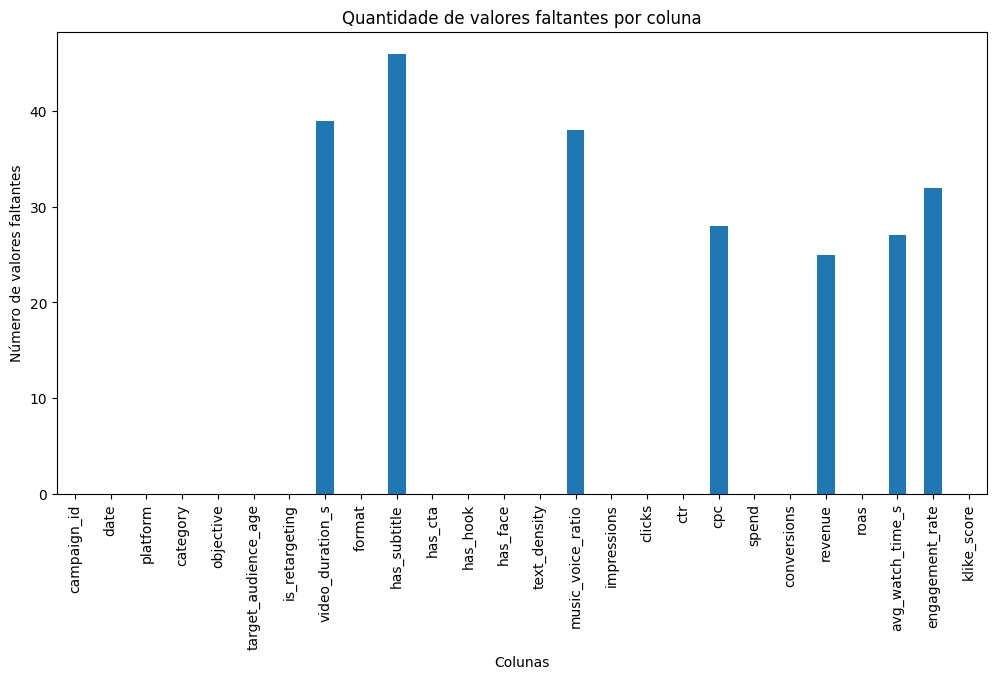

In [591]:
missing_counts = df.isna().sum()

# Plot
plt.figure(figsize=(12,6))
missing_counts.plot(kind='bar')
plt.title("Quantidade de valores faltantes por coluna")
plt.ylabel("Número de valores faltantes")
plt.xlabel("Colunas")
plt.show()

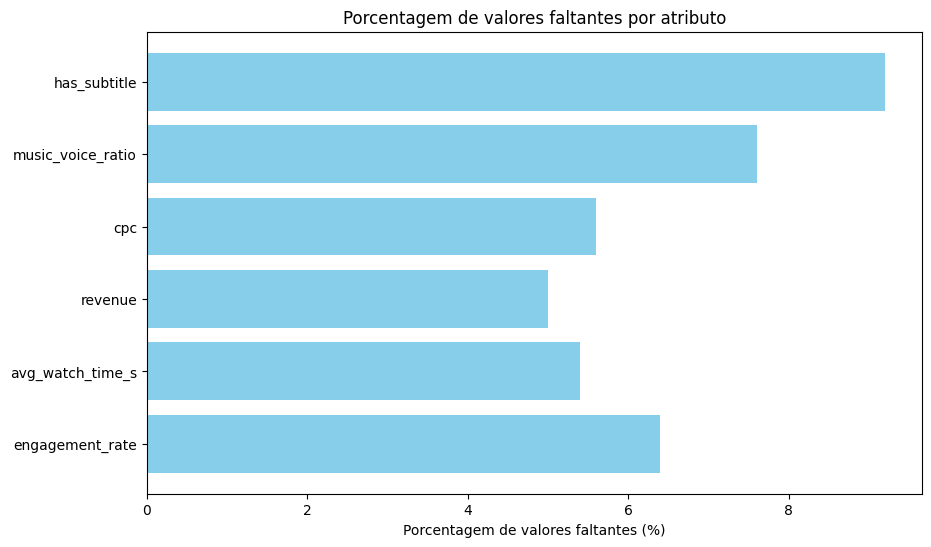

In [592]:
# Lista das colunas e porcentagens
cols = ['has_subtitle', 'music_voice_ratio', 'cpc', 'revenue', 'avg_watch_time_s', 'engagement_rate']
percentages = [9.2, 7.6, 5.6, 5.0, 5.4, 6.4]

plt.figure(figsize=(10,6))
plt.barh(cols, percentages, color='skyblue')
plt.xlabel("Porcentagem de valores faltantes (%)")
plt.title("Porcentagem de valores faltantes por atributo")
plt.gca().invert_yaxis()  # para mostrar do maior para o menor
plt.show()

In [593]:
# Porcentagem de valores faltantes
missing_percent = df.isna().mean() * 100

# Exibir
print(missing_percent)

campaign_id            0.0
date                   0.0
platform               0.0
category               0.0
objective              0.0
target_audience_age    0.0
is_retargeting         0.0
video_duration_s       7.8
format                 0.0
has_subtitle           9.2
has_cta                0.0
has_hook               0.0
has_face               0.0
text_density           0.0
music_voice_ratio      7.6
impressions            0.0
clicks                 0.0
ctr                    0.0
cpc                    5.6
spend                  0.0
conversions            0.0
revenue                5.0
roas                   0.0
avg_watch_time_s       5.4
engagement_rate        6.4
klike_score            0.0
dtype: float64


## Tratamento de valores faltantes

In [594]:
# Qual % é nulo?
df['has_subtitle'].isnull().mean()

# Os nulos têm algum padrão? (ex: só em uma plataforma?)
df[df['has_subtitle'].isnull()]['platform'].value_counts()
df['has_subtitle'] = df['has_subtitle'].fillna(False)

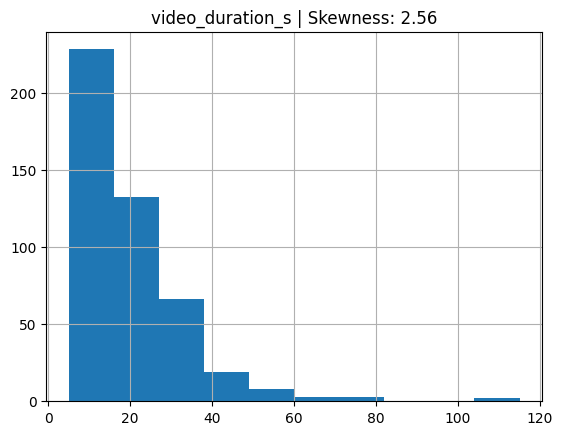

count    461.000000
mean      19.392625
std       13.529351
min        5.000000
25%       11.000000
50%       16.000000
75%       25.000000
max      115.000000
Name: video_duration_s, dtype: float64
Skewness: 2.555326978876786


In [595]:
# Skewness > 1 -> mediana
skew_val = df['video_duration_s'].skew()

fig, ax = plt.subplots()
df['video_duration_s'].hist(ax=ax)
ax.set_title(f'video_duration_s | Skewness: {skew_val:.2f}')
plt.show()

print(df['video_duration_s'].describe())
print(f"Skewness: {skew_val}")

# Preenche NaNs com a mediana da coluna
df['video_duration_s'] = df['video_duration_s'].fillna(df['video_duration_s'].median())

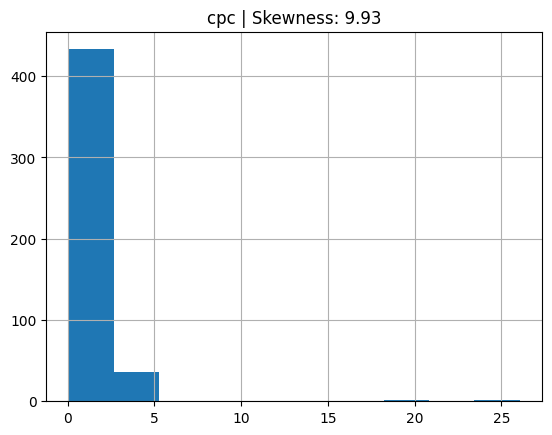

count    472.000000
mean       1.112903
std        1.955625
min        0.050000
25%        0.530000
50%        0.710000
75%        1.020000
max       26.050000
Name: cpc, dtype: float64
Skewness: 9.925325514170042


In [596]:
skew_val = df['cpc'].skew()

fig, ax = plt.subplots()
df['cpc'].hist(ax=ax)
ax.set_title(f'cpc | Skewness: {skew_val:.2f}')
plt.show()

print(df['cpc'].describe())
print(f"Skewness: {skew_val}")

df['cpc'] = df['cpc'].fillna(df['cpc'].median())

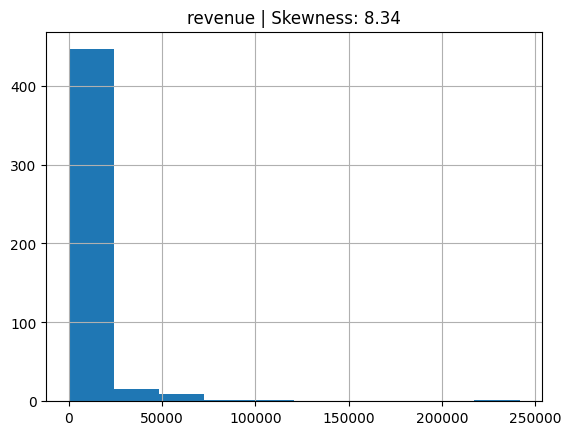

count       475.000000
mean       6367.936863
std       19267.180696
min           0.000000
25%         262.175000
50%        1201.050000
75%        4189.025000
max      241597.290000
Name: revenue, dtype: float64
Skewness: 8.343113090892805


In [597]:
skew_val = df['revenue'].skew()

fig, ax = plt.subplots()
df['revenue'].hist(ax=ax)
ax.set_title(f'revenue | Skewness: {skew_val:.2f}')
plt.show()

print(df['revenue'].describe())
print(f"Skewness: {skew_val}")

df['revenue'] = df['revenue'].fillna(df['revenue'].median())

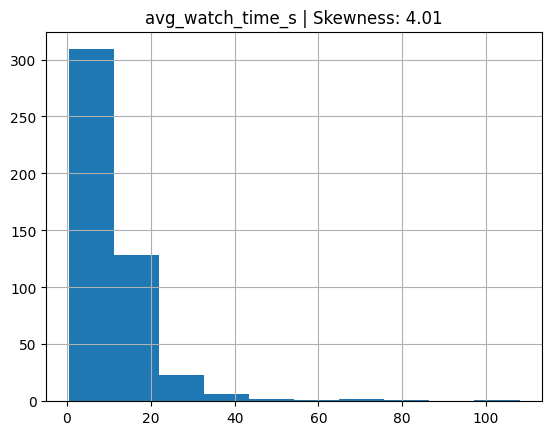

count    473.000000
mean      10.664271
std       10.533275
min        0.400000
25%        4.700000
50%        7.700000
75%       13.900000
max      108.000000
Name: avg_watch_time_s, dtype: float64
Skewness: 4.014319404951158


In [598]:
skew_val = df['avg_watch_time_s'].skew()

fig, ax = plt.subplots()
df['avg_watch_time_s'].hist(ax=ax)
ax.set_title(f'avg_watch_time_s | Skewness: {skew_val:.2f}')
plt.show()

print(df['avg_watch_time_s'].describe())
print(f"Skewness: {skew_val}")

df['avg_watch_time_s'] = df['avg_watch_time_s'].fillna(df['avg_watch_time_s'].median())

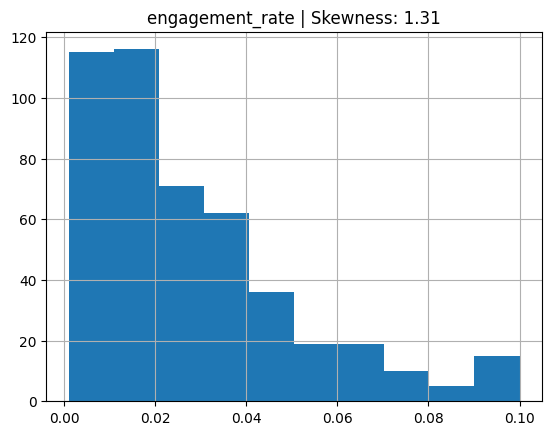

count    468.000000
mean       0.027952
std        0.023057
min        0.001000
25%        0.011100
50%        0.021400
75%        0.038800
max        0.100000
Name: engagement_rate, dtype: float64
Skewness: 1.3073316203723133


In [599]:
skew_val = df['engagement_rate'].skew()

fig, ax = plt.subplots()
df['engagement_rate'].hist(ax=ax)
ax.set_title(f'engagement_rate | Skewness: {skew_val:.2f}')
plt.show()

print(df['engagement_rate'].describe())
print(f"Skewness: {skew_val}")

df['engagement_rate'] = df['engagement_rate'].fillna(df['engagement_rate'].median())

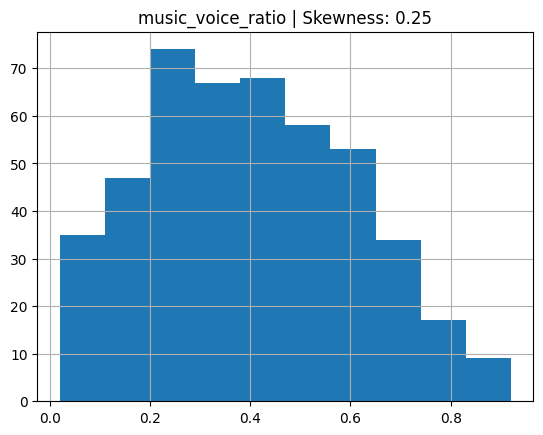

count    462.000000
mean       0.399848
std        0.202674
min        0.020000
25%        0.230000
50%        0.385000
75%        0.550000
max        0.920000
Name: music_voice_ratio, dtype: float64
Skewness: 0.24555145897923725


In [600]:
df['music_voice_ratio'].skew()
skew_val = df['music_voice_ratio'].skew()

fig, ax = plt.subplots()
df['music_voice_ratio'].hist(ax=ax)
ax.set_title(f'music_voice_ratio | Skewness: {skew_val:.2f}')
plt.show()

print(df['music_voice_ratio'].describe())
print(f"Skewness: {skew_val}")

df['music_voice_ratio'] = df['music_voice_ratio'].fillna(df['music_voice_ratio'].mean())

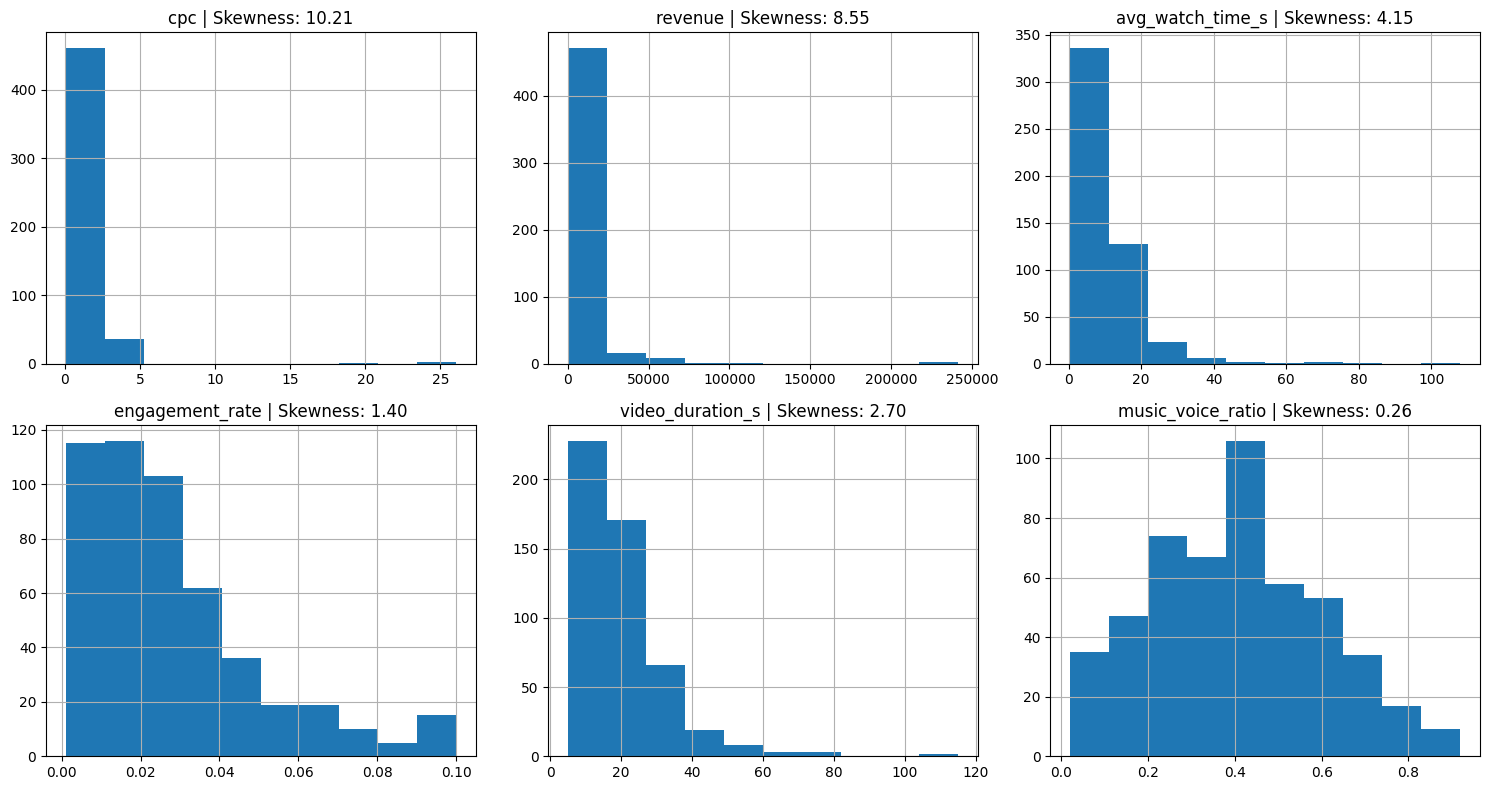

In [601]:
cols = ['cpc', 'revenue', 'avg_watch_time_s', 'engagement_rate', 'video_duration_s','music_voice_ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    skew_val = df[col].skew()
    df[col].hist(ax=axes[i])
    axes[i].set_title(f'{col} | Skewness: {skew_val:.2f}')

plt.tight_layout()
plt.show()

## Novos Atributos

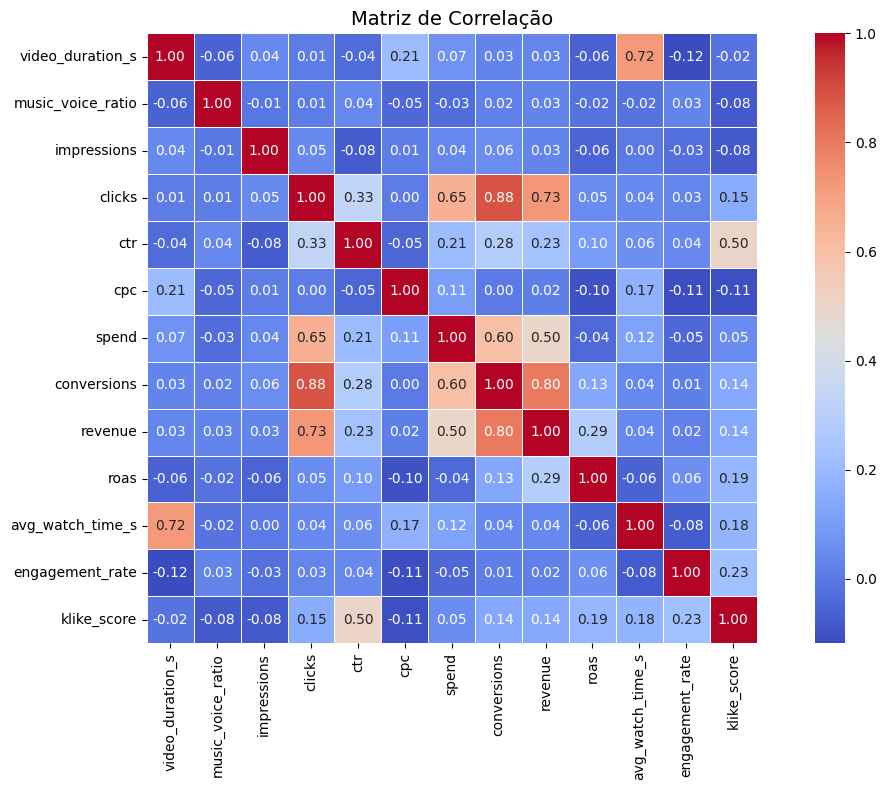

In [602]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

In [603]:
# Datas em seus formatos puros não representam informação útil para modelos
# Entretanto podemos derivar alguns atributos, como o dia da semana que foi colocado e uma flag se é final de semana
df['date'] = pd.to_datetime(df['date'])
df['dia_da_semana'] = df['date'].dt.dayofweek # 0 é segunda
df['fl_final_semana'] = df['dia_da_semana'].isin([5, 6]).astype(int)
# talvez possamos encontrar algum padrão referente à época do mes
df_dias = pd.DataFrame()
df_dias['data'] = df['date']
df_dias['dias_mes'] = df_dias['data'].dt.days_in_month
df_dias['proporcao_dia'] = df_dias['data'].dt.day/df_dias['dias_mes']
df_dias['quartil_mes'] = pd.cut(
                                df_dias['proporcao_dia'],
                                bins=[0,0.25,0.5,0.75,1],
                                labels=['inicio','meio1','meio2','fim'],
                                include_lowest=True)
mapping = {'inicio':0,'meio1':1,'meio2':2,'fim':3}
df['posicao_mes_veiculacao'] = df_dias['quartil_mes'].map(mapping)

In [604]:
# Vamos derivar um atributo relacionado a estratégia x dia x plataforma
df['objective_platform'] = df['objective'] + "_" + df['platform']
df['platform_weekend'] = df['platform'] + '_' + df['fl_final_semana'].astype(str)
df['obj_mes'] = df['objective'] + '_' + df['posicao_mes_veiculacao'].astype(str)
df = pd.get_dummies(
    df,
    columns=['objective_platform', 'platform_weekend','obj_mes'],
    drop_first=True
)

In [605]:
# Categorizar conversoes e impressoes (importante para o modelo), escala pesada -> usar quartis
df['impressions_cat'] = pd.qcut(
    df['impressions'],
    q=4,
    labels=['baixo', 'medio_baixo', 'medio_alto', 'alto'],
    duplicates='drop'
)

df['conversions_cat'] = pd.qcut(
    df['conversions'],
    q=4,
    labels=['baixo', 'medio_baixo', 'medio_alto', 'alto'],
    duplicates='drop'
)

In [606]:
# transformar a duracao do vídeo em categoria facilita a análise e cria features robustas a outliers

df['video_duration_cat'] = pd.cut(
    df['video_duration_s'],
    bins=[0, 10, 20, 40, 120],
    labels=['muito_curto', 'curto', 'medio', 'longo']
)


In [607]:
#Identifica, para cada objetivo, em qual momento do mês a taxa de conversão é maior e cria uma variável indicando se a campanha está sendo exibida nesse período ideal.
df_group = df.groupby(['objective', 'posicao_mes_veiculacao']).agg({
    'conversions': 'sum',
    'impressions': 'sum'
}).reset_index()

df_group['conv_rate'] = df_group['conversions'] / df_group['impressions']
df_best = df_group.loc[
    df_group.groupby('objective')['conv_rate'].idxmax()
]
best_map = dict(zip(df_best['objective'], df_best['posicao_mes_veiculacao']))
df['best_pos_mes_obj'] = df['objective'].map(best_map)
df['is_best_moment'] = (
    df['posicao_mes_veiculacao'] == df['best_pos_mes_obj']
).astype(int)

df['conv_rate'] = df_group['conv_rate']

In [608]:
df['conv_rate_by_duration'] = df.groupby('video_duration_cat')['conv_rate'].transform('mean')
df['conv_rate_diff_duration'] = df['conv_rate'] - df['conv_rate_by_duration']

In [609]:
df['duration_obj'] = df['video_duration_cat'].astype(str) + '_' + df['objective']
df = pd.get_dummies(df, columns=['duration_obj'], drop_first=True)

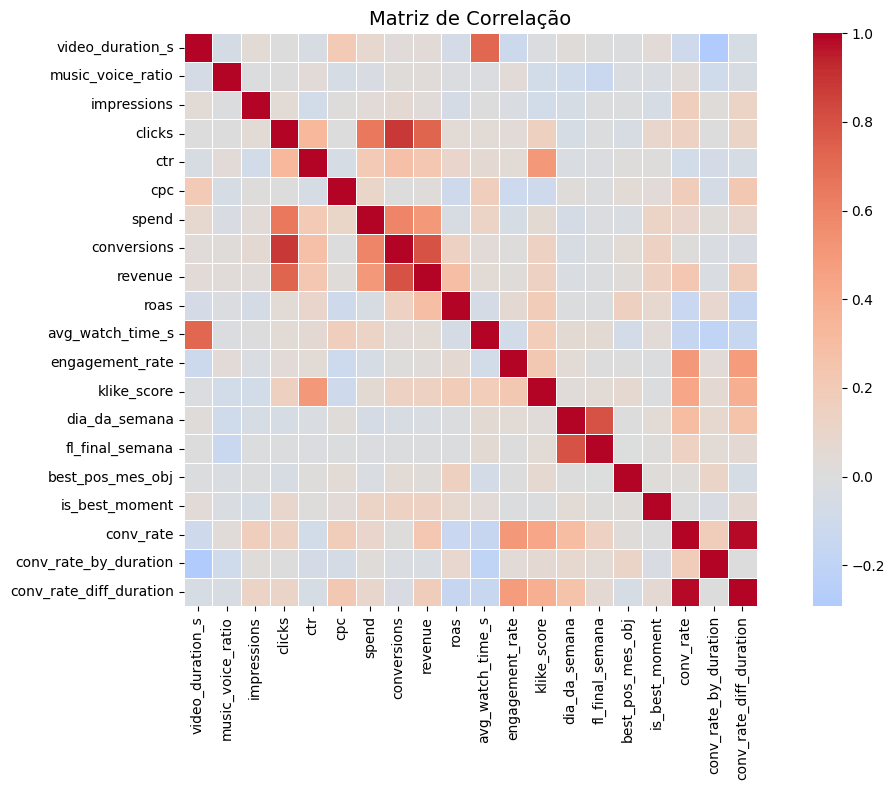

In [610]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

In [611]:
df['porcentagem_assistida'] = df['avg_watch_time_s'] / df['video_duration_s']  # % do vídeo assistido
df['receita_x_click'] = df['revenue'] / (df['clicks'] + 1)
df['custo_x_conversao'] = df['spend'] / (df['conversions'] + 1)
df['ctr_x_roas'] = df['ctr'] * df['roas']

In [612]:
creative_cols = ['has_subtitle', 'has_cta', 'has_hook', 'has_face']
df['completude_criativa'] = df[creative_cols].sum(axis=1)  # 0 a 4

In [613]:
age_map = {'18-24': 0, '25-34': 1, '35-44': 2, '45+': 3}
df['target_audience_age_cat'] = df['target_audience_age'].map(age_map)

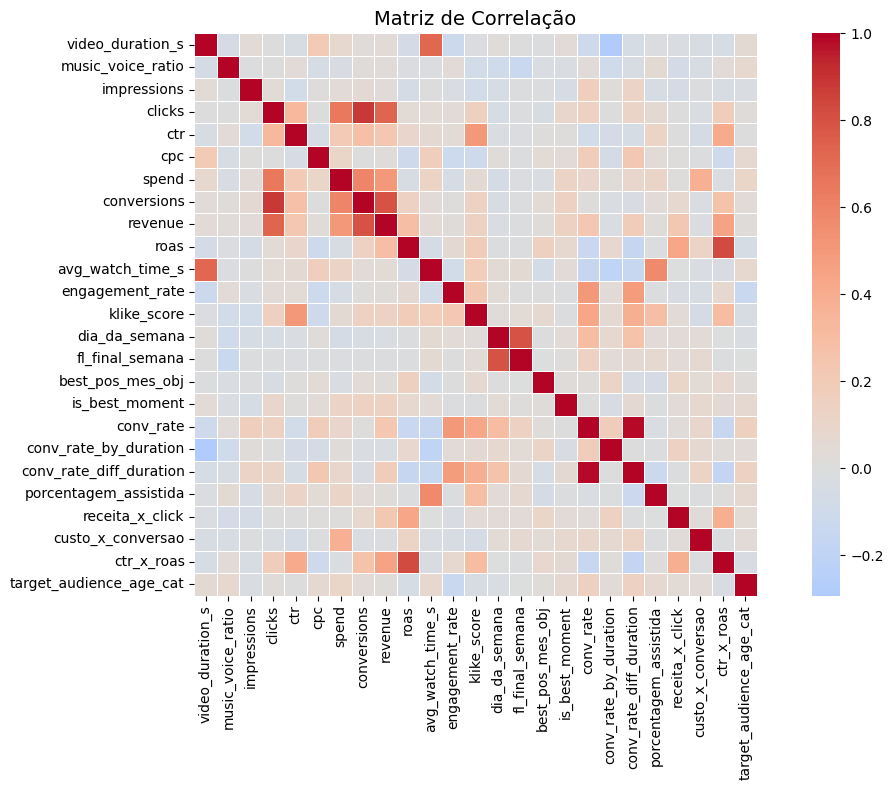

In [614]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

In [615]:
mapping = {'low': 0, 'medium': 1, 'high': 2}
df['text_density_cat'] = df['text_density'].map(mapping)

In [616]:
df['fl_replay'] = (df['avg_watch_time_s'] > df['video_duration_s']).astype(int)

df['avg_watch_time_s'] = df[['avg_watch_time_s', 'video_duration_s']].min(axis=1)
df['porcentagem_assistida'] = df['avg_watch_time_s'] / df['video_duration_s']

## Outliers

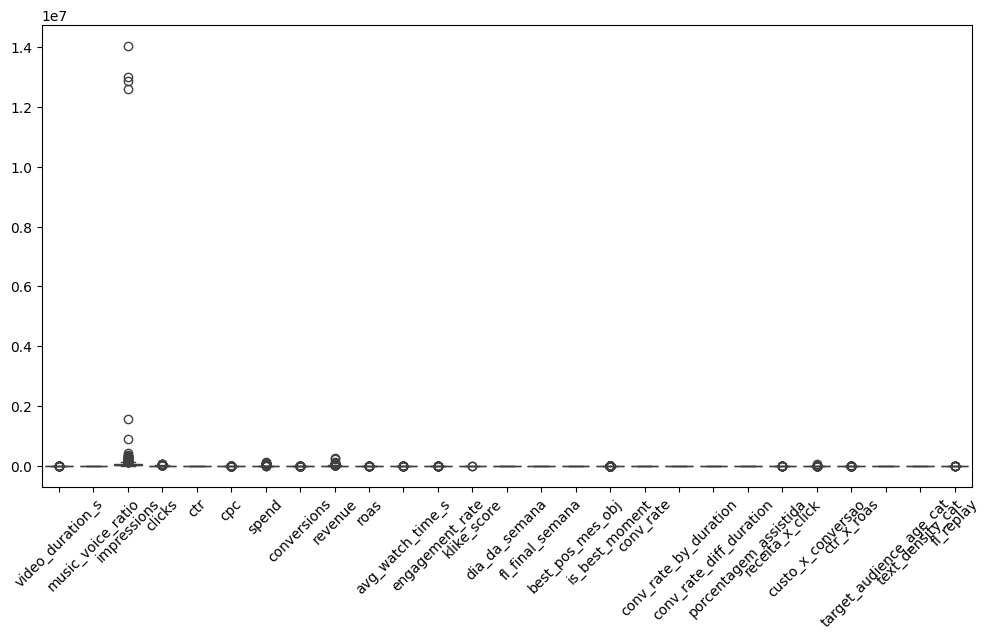

In [617]:
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

Colunas com maior diferença de magnitude: ['impressions', 'revenue', 'spend', 'clicks', 'custo_x_conversao', 'conversions']


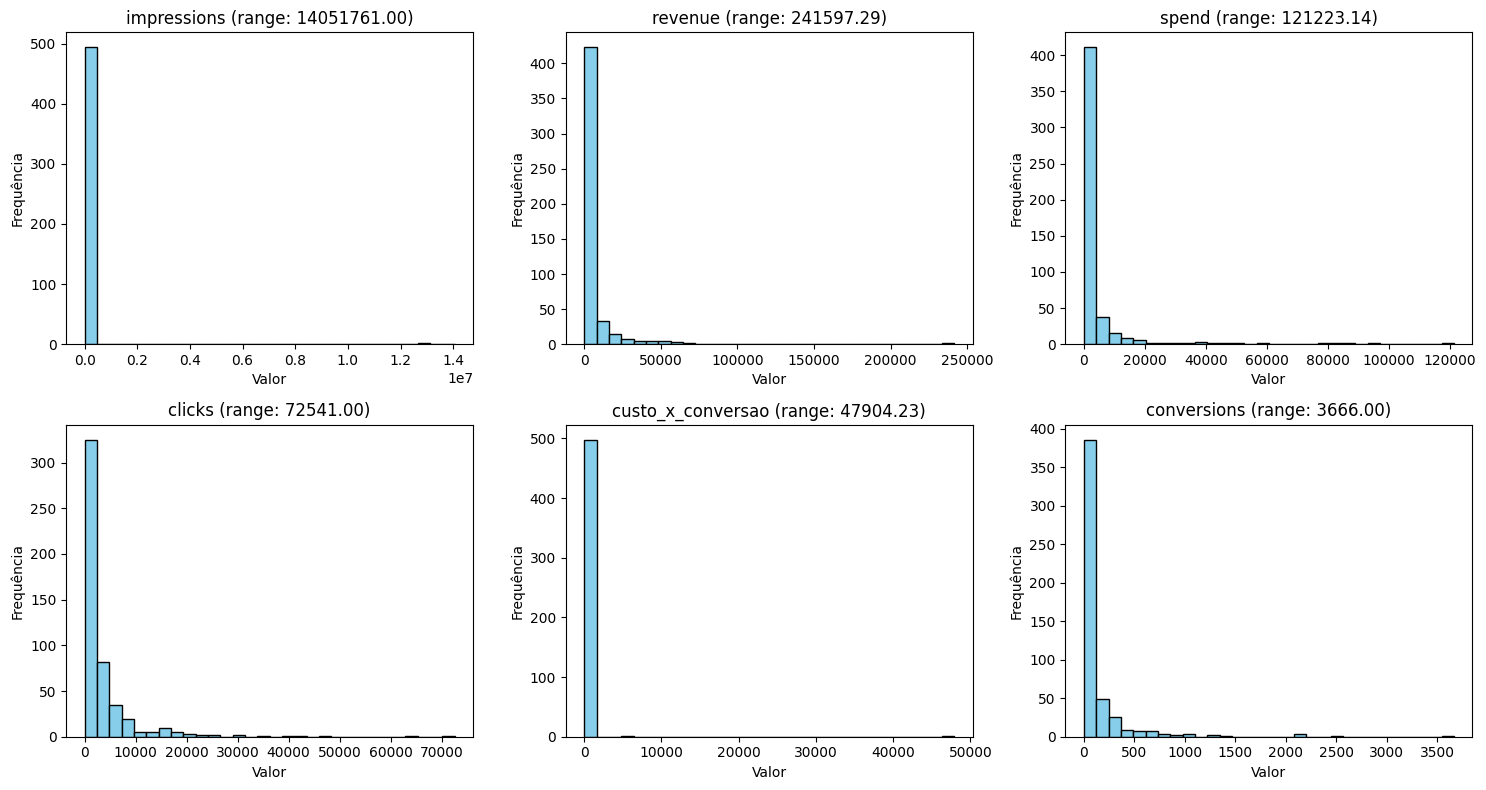

In [618]:
atributos = df.select_dtypes(include='number').columns

# Calcula a diferença entre máximo e mínimo
ranges = df[atributos].max() - df[atributos].min()

# Seleciona as top N colunas com maior diferença
top_n = 6
top_atributos = ranges.sort_values(ascending=False).head(top_n).index
print("Colunas com maior diferença de magnitude:", list(top_atributos))
n = len(top_atributos)
cols_subplot = 3
rows_subplot = math.ceil(n / cols_subplot)

plt.figure(figsize=(5*cols_subplot, 4*rows_subplot))
for i, col in enumerate(top_atributos, 1):
    plt.subplot(rows_subplot, cols_subplot, i)
    plt.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} (range: {ranges[col]:.2f})")
    plt.xlabel("Valor")
    plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

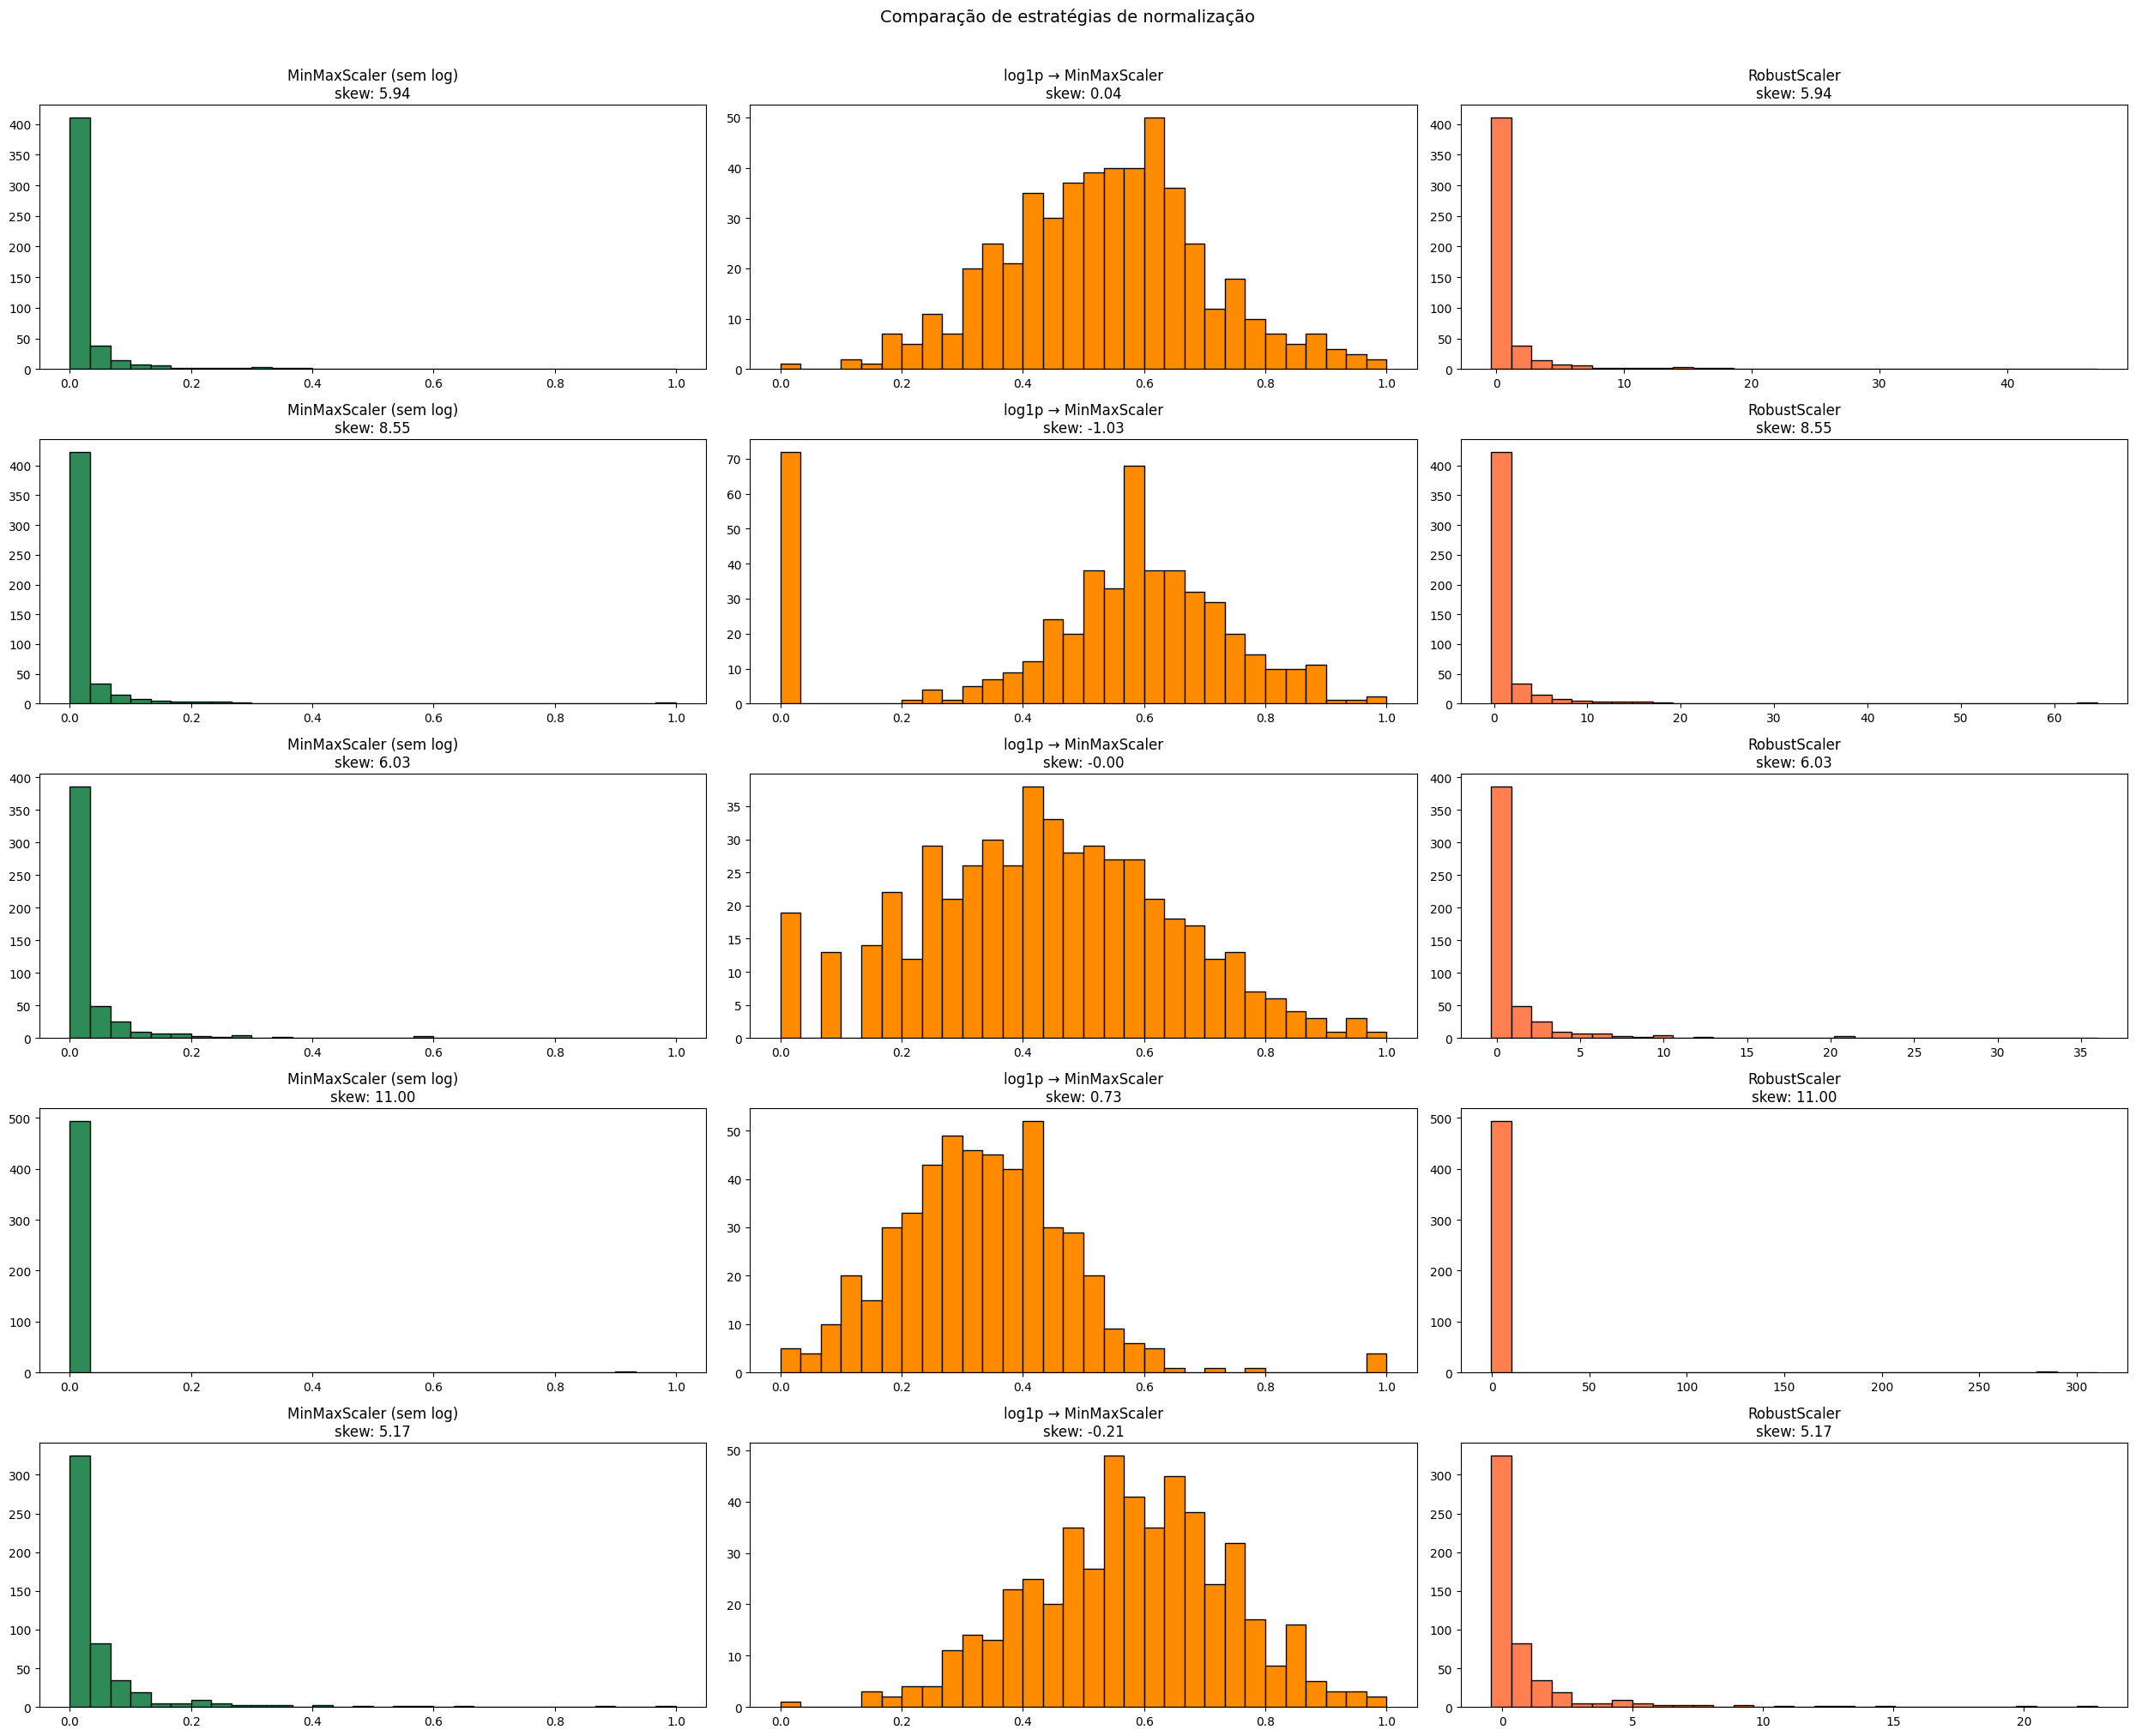

In [619]:
cols = ['spend', 'revenue', 'conversions', 'impressions', 'clicks']

fig, axes = plt.subplots(len(cols), 3, figsize=(25, 4 * len(cols)))

for i, col in enumerate(cols):
    data     = df[col].dropna().values.reshape(-1, 1)
    log_data = np.log1p(data)

    minmax_raw  = MinMaxScaler().fit_transform(data).flatten()
    minmax_log  = MinMaxScaler().fit_transform(log_data).flatten()
    robust_raw  = RobustScaler().fit_transform(data).flatten()

    skew_orig   = df[col].skew()
    skew_log    = pd.Series(log_data.flatten()).skew()
    skew_minmax = pd.Series(minmax_raw).skew()
    skew_robust = pd.Series(robust_raw).skew()

    axes[i, 0].hist(minmax_raw, bins=30, color='seagreen',   edgecolor='black')
    axes[i, 0].set_title(f'MinMaxScaler (sem log)\nskew: {skew_minmax:.2f}')

    axes[i, 1].hist(minmax_log, bins=30, color='darkorange',  edgecolor='black')
    axes[i, 1].set_title(f'log1p → MinMaxScaler\nskew: {skew_log:.2f}')

    axes[i, 2].hist(robust_raw, bins=30, color='coral',       edgecolor='black')
    axes[i, 2].set_title(f'RobustScaler\nskew: {skew_robust:.2f}')

plt.suptitle('Comparação de estratégias de normalização', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [620]:

cols = ['impressions', 'clicks', 'spend', 'revenue']
scaler = MinMaxScaler()

for col in cols:
    # Aplica log
    log_col = np.log1p(df[col])
    
    # Aplica MinMax e cria nova coluna
    df[col + '_lg_mm'] = scaler.fit_transform(log_col.values.reshape(-1, 1))

In [621]:
derived_cols = ['custo_x_conversao', 'receita_x_click', 'ctr_x_roas', 'porcentagem_assistida']
scaler = MinMaxScaler()

for col in derived_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)
    log_col = np.log1p(df[col])
    df[col + '_lg_mm'] = scaler.fit_transform(log_col.values.reshape(-1, 1))

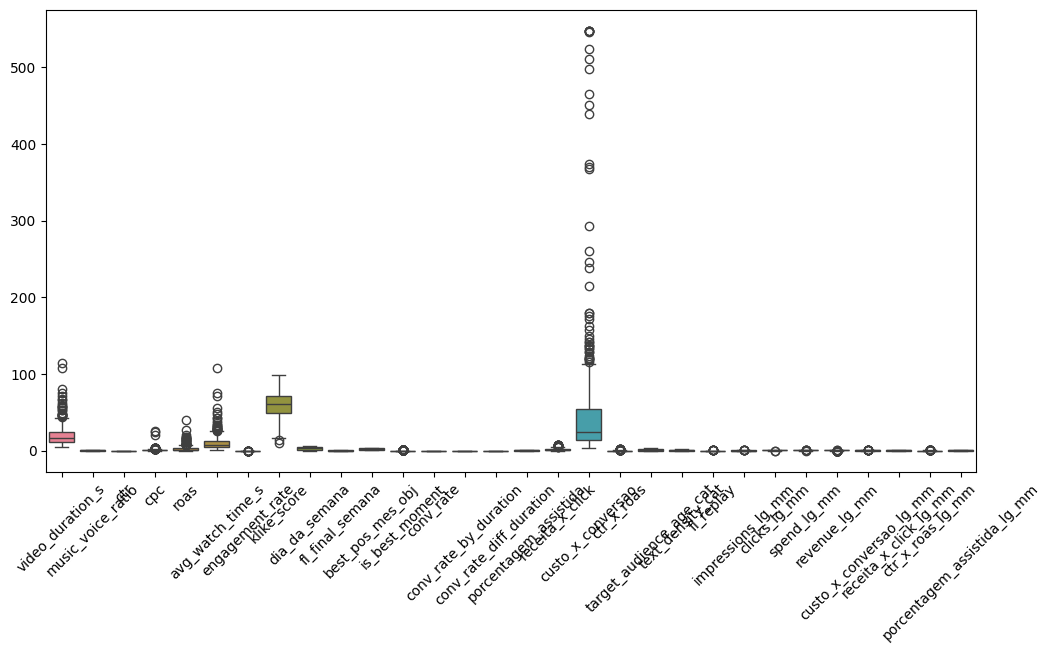

In [622]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop(['spend','revenue','conversions','clicks','impressions'])
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

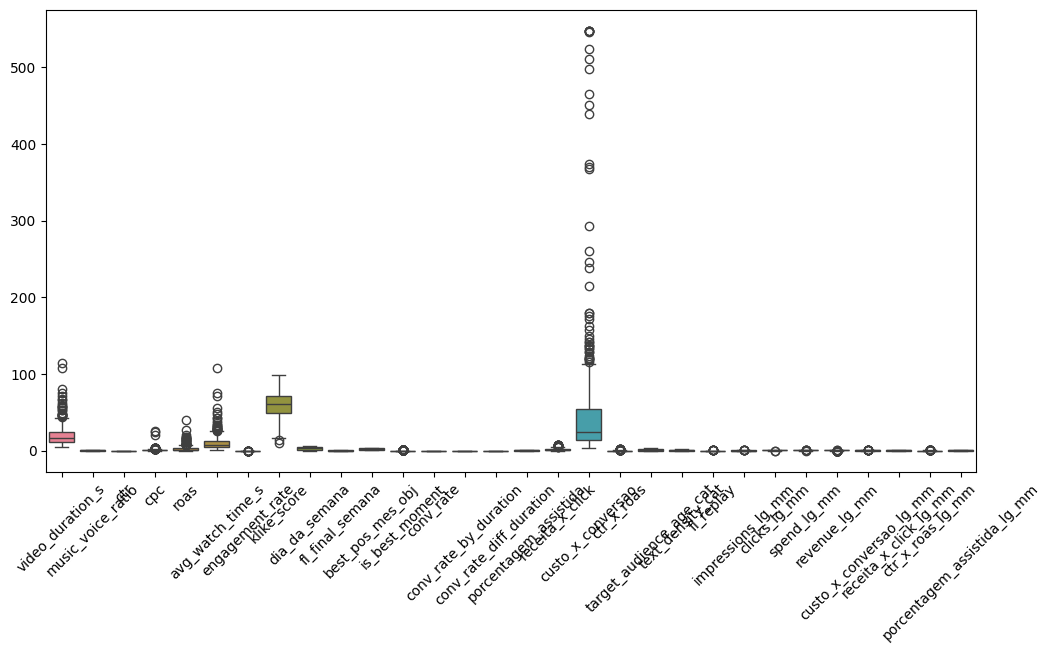

In [623]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop(['spend','revenue','conversions','clicks','impressions'])
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

In [624]:
for col in ['engagement_rate', 'music_voice_ratio']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in ['engagement_rate', 'music_voice_ratio']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

In [625]:
df['klike_score'].value_counts()

klike_score
53.8    6
50.8    5
61.4    4
46.5    4
75.5    4
       ..
57.2    1
57.0    1
35.6    1
26.1    1
41.8    1
Name: count, Length: 335, dtype: int64

In [626]:
df.isna().sum()

campaign_id                    0
date                           0
platform                       0
category                       0
objective                      0
                              ..
revenue_lg_mm                  0
custo_x_conversao_lg_mm        0
receita_x_click_lg_mm          0
ctr_x_roas_lg_mm               0
porcentagem_assistida_lg_mm    0
Length: 110, dtype: int64

In [627]:
for col in ['video_duration_s', 'avg_watch_time_s','ctr', 'roas', 'cpc']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)
    log_col = np.log1p(df[col])
    df[col + '_lg_mm'] = scaler.fit_transform(log_col.values.reshape(-1, 1))

for col in ['conv_rate', 'conv_rate_by_duration', 'conv_rate_diff_duration']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

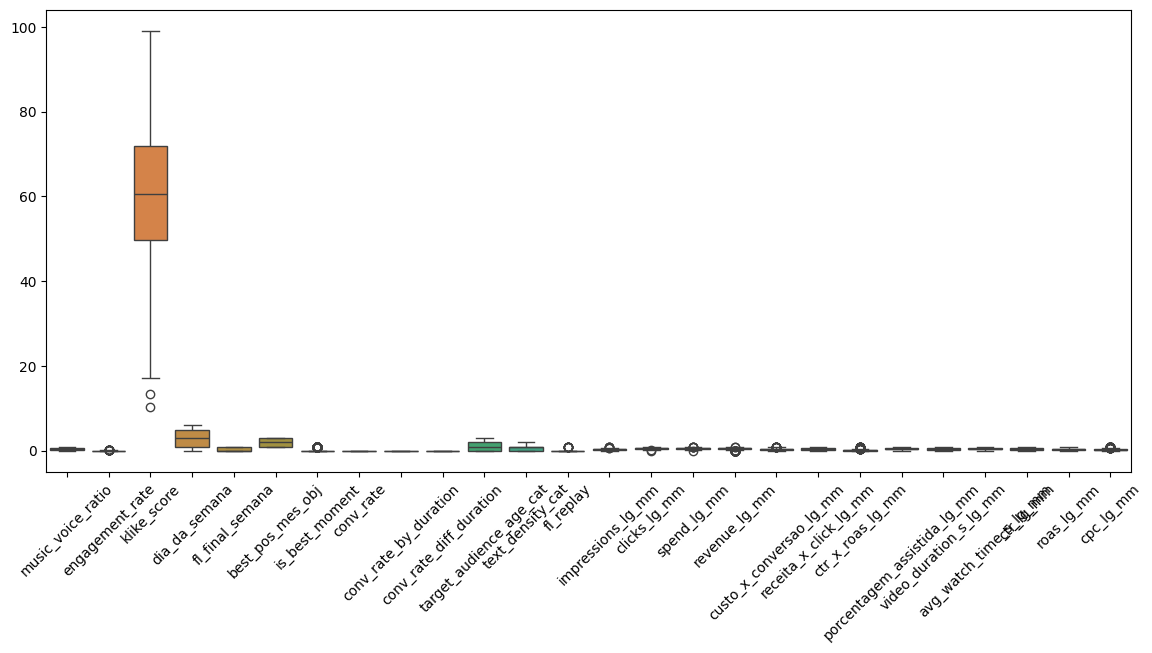

In [628]:
# Exclui as originais que têm versão normalizada
cols_excluir = ['avg_watch_time_s','video_duration_s','ctr', 'roas', 'cpc','spend', 'revenue', 'conversions', 'clicks', 'impressions',
                'custo_x_conversao', 'receita_x_click', 'ctr_x_roas', 'porcentagem_assistida']

numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = [c for c in numeric_cols if c not in cols_excluir]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

In [638]:
# Colunas que não entram no modelo
cols_drop = [
    # identificadores
    'campaign_id', 'date',
    
    # originais que têm versão normalizada
    'avg_watch_time_s','video_duration_s','ctr', 'roas', 'cpc','spend', 'revenue', 'conversions', 'clicks', 'impressions',
    'custo_x_conversao', 'receita_x_click', 'ctr_x_roas', 'porcentagem_assistida'
    
    # categóricas originais que viraram dummies ou ordinais
    'platform', 'category', 'objective', 'target_audience_age',
    'text_density', 'format',
    
    # categóricas que viraram cat/ordinal
    'video_duration_cat', 'impressions_cat', 'conversions_cat',
    
    # auxiliares de cálculo
    'best_pos_mes_obj',
]

df_model = df.drop(columns=cols_drop, errors='ignore')

# Confirma que não sobrou nada não-numérico
print(df_model.dtypes.value_counts())
print(df_model.shape)

bool        63
float64     20
int64        7
int32        1
category     1
Name: count, dtype: int64
(500, 92)


In [635]:
df_model = pd.get_dummies(df_model, columns=['platform'], drop_first=True)
df_model['has_subtitle'] = df_model['has_subtitle'].astype(int)
df_model['completude_criativa'] = df_model['completude_criativa'].astype(int)

In [639]:
df_model.to_csv('./data/df_model.csv', index=False)